🟡 1. Descriptive Statistics

In [1]:
import numpy as np
from scipy import stats

data = np.random.randint(-20, 61, size=20)

mean = np.mean(data)
mode = stats.mode(data, keepdims=True) 
median = np.median(data)
sorted_data =  np.sort(data)

variance = np.var(data)
stdDeviation = np.std(data)

print(sorted_data)
print("Mean ",mean," mode: ",mode[0]," median: ",median," variance: ",variance," std. deviation: ",stdDeviation)

[-17  -6  -2  -1   2   8   9  12  20  21  29  36  37  37  38  42  43  45
  48  50]
Mean  22.55  mode:  [37]  median:  25.0  variance:  402.74750000000006  std. deviation:  20.06856995403509


🔵 2. Probability Basics

In [3]:
import random

sample_space = {1, 2, 3, 4, 5, 6}


# An event is a subset of the sample space. (even number, a number greater than...)
event_even = {2, 4, 6}        # Event: roll an even number
event_gt_3 = {4, 5, 6}        # Event: roll greater than 3
event_prime = {2, 3, 5}       # Event: roll a prime number


# Simulate a die roll
roll = random.randint(1, 6)

# For equally likely outcomes, the probability of an event is: n of fav outcomes / n of possible outcomes

# Theoretical probabilities
P_even = len(event_even) / len(sample_space)
P_gt_3 = len(event_gt_3) / len(sample_space)
P_prime = len(event_prime) / len(sample_space)

print("Theoretical Probabilities:")
print(f"P(even)   = {P_even}")
print(f"P(> 3)    = {P_gt_3}")
print(f"P(prime)  = {P_prime}")


Theoretical Probabilities:
P(even)   = 0.5
P(> 3)    = 0.5
P(prime)  = 0.5


Empirical probability

In [ ]:
import random

# Simulate 10,000 die rolls
n_trials = 10_000
rolls = [random.randint(1, 6) for _ in range(n_trials)]

# Count occurrences
count_even = sum(1 for r in rolls if r in event_even)
count_gt_3 = sum(1 for r in rolls if r in event_gt_3)
count_prime = sum(1 for r in rolls if r in event_prime)

# Empirical probabilities
P_even_empirical = count_even / n_trials
P_gt_3_empirical = count_gt_3 / n_trials
P_prime_empirical = count_prime / n_trials

print("\nEmpirical Probabilities (from simulation):")
print(f"P(even)   ≈ {P_even_empirical:.4f}")
print(f"P(> 3)    ≈ {P_gt_3_empirical:.4f}")
print(f"P(prime)  ≈ {P_prime_empirical:.4f}")


Conditional probability 

In [ ]:
sample_space = {1, 2, 3, 4, 5, 6}
A = {2, 4, 6}         # Event A: even
B = {4, 5, 6}         # Event B: greater than 3

# Intersection
A_and_B = A.intersection(B)

# Probabilities
P_A_and_B = len(A_and_B) / len(sample_space)
P_B = len(B) / len(sample_space)

# Conditional probability
P_A_given_B = P_A_and_B / P_B

print(f"P(A ∩ B) = {P_A_and_B}")
print(f"P(B)     = {P_B}")
print(f"P(A | B) = {P_A_given_B}")


In [ ]:
#discrete and continous variables 
discrete_data = np.random.randint(0, 10, size=10)

# Continuous: temperature readings
continuous_data = np.random.uniform(36.0, 38.0, size=10)

Distributions

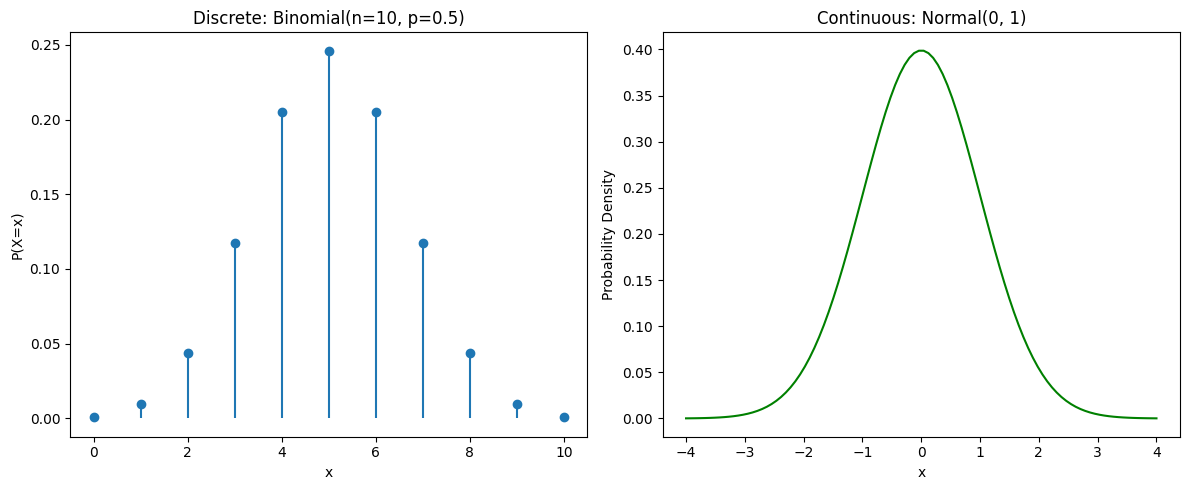

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, norm

# Discrete: Binomial distribution
x_discrete = np.arange(0, 11)
y_binom = binom.pmf(x_discrete, n=10, p=0.5)

# Continuous: Normal distribution
x_cont = np.linspace(-4, 4, 100)
y_norm = norm.pdf(x_cont, loc=0, scale=1)

# Plotting
plt.figure(figsize=(12, 5))

# Discrete plot
plt.subplot(1, 2, 1)
plt.stem(x_discrete, y_binom, basefmt=" ")
plt.title("Discrete: Binomial(n=10, p=0.5)")
plt.xlabel("x")
plt.ylabel("P(X=x)")

# Continuous plot
plt.subplot(1, 2, 2)
plt.plot(x_cont, y_norm, color="green")
plt.title("Continuous: Normal(0, 1)")
plt.xlabel("x")
plt.ylabel("Probability Density")

plt.tight_layout()
plt.show()


Plot distributions

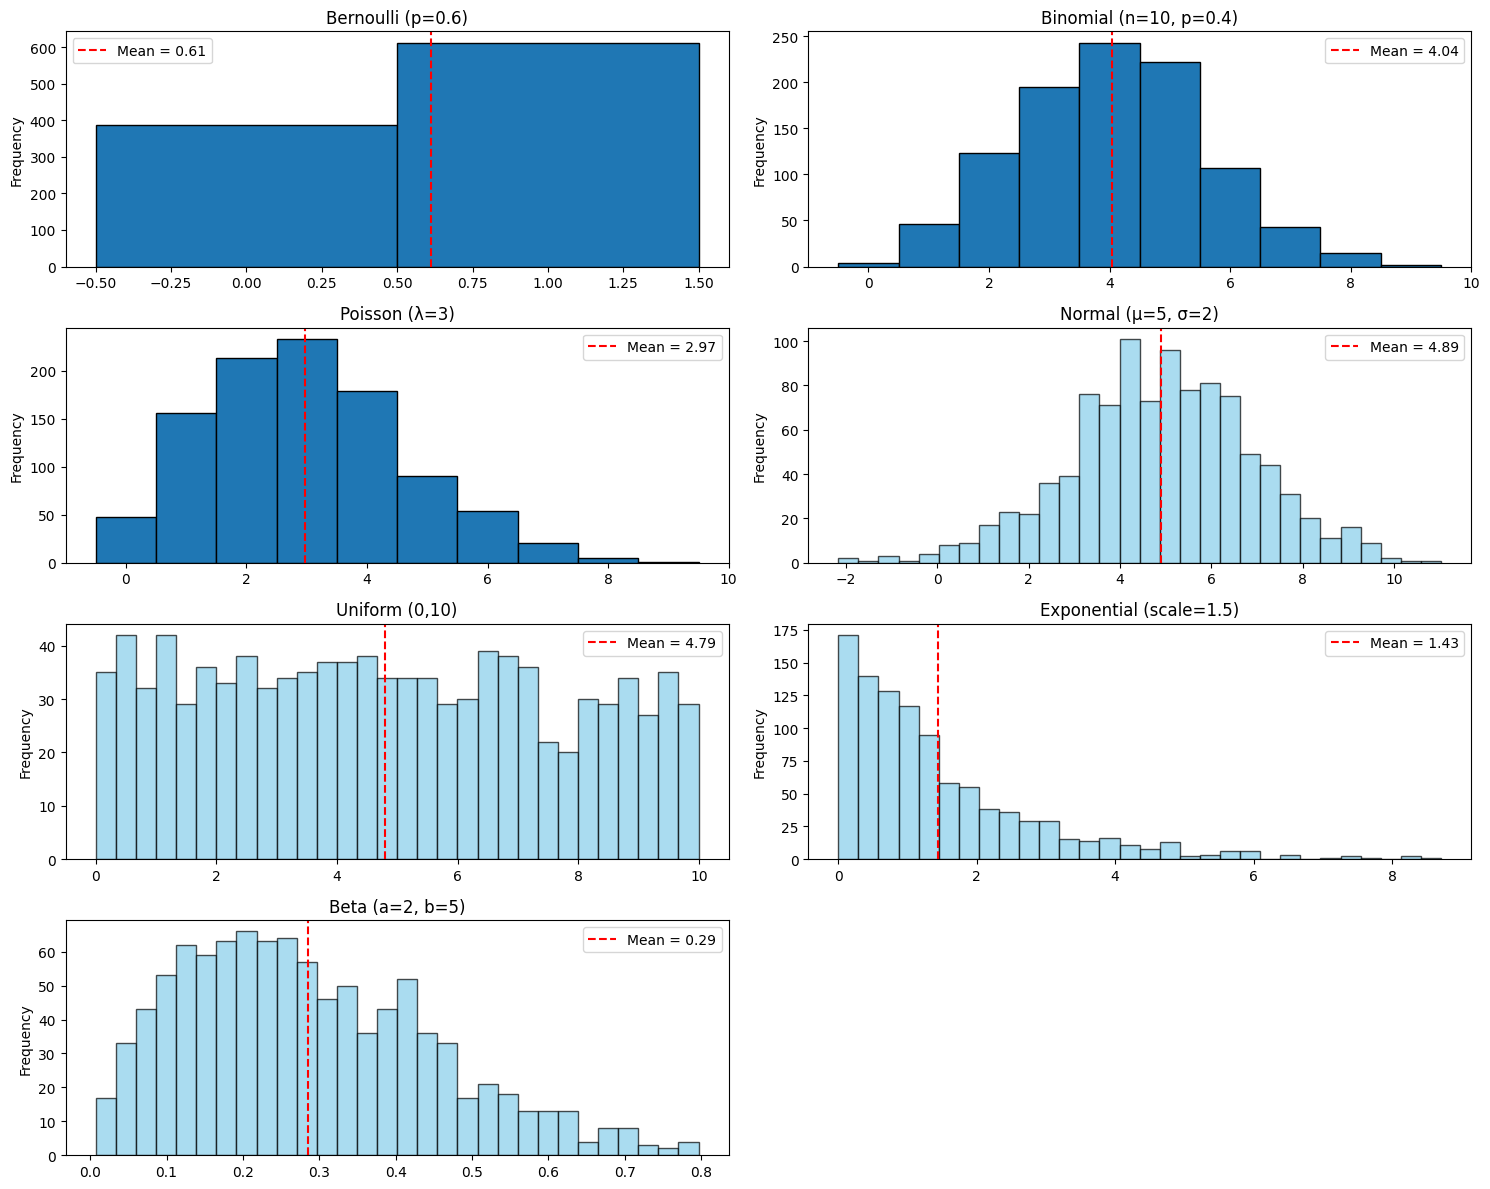

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import bernoulli, binom, poisson, norm, uniform, expon, beta

# Set random seed for reproducibility
np.random.seed(42)

# Sample size
n = 1000

# Simulate distributions
data_dict = {
    "Bernoulli (p=0.6)": (bernoulli.rvs(p=0.6, size=n), True),
    "Binomial (n=10, p=0.4)": (binom.rvs(n=10, p=0.4, size=n), True),
    "Poisson (λ=3)": (poisson.rvs(mu=3, size=n), True),
    "Normal (μ=5, σ=2)": (norm.rvs(loc=5, scale=2, size=n), False),
    "Uniform (0,10)": (uniform.rvs(loc=0, scale=10, size=n), False),
    "Exponential (scale=1.5)": (expon.rvs(scale=1.5, size=n), False),
    "Beta (a=2, b=5)": (beta.rvs(a=2, b=5, size=n), False)
}

# Plot setup
fig, axs = plt.subplots(4, 2, figsize=(15, 12))
axs = axs.flatten()

for i, (name, (data, is_discrete)) in enumerate(data_dict.items()):
    if is_discrete:
        bins = range(int(min(data)), int(max(data)) + 2)
        axs[i].hist(data, bins=bins, edgecolor='black', align='left')
    else:
        axs[i].hist(data, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    
    mean = np.mean(data)
    axs[i].axvline(mean, color='red', linestyle='--', label=f"Mean = {mean:.2f}")
    axs[i].set_title(name)
    axs[i].legend()
    axs[i].set_ylabel("Frequency")

# Turn off the last empty subplot if odd number
if len(data_dict) < len(axs):
    axs[-1].axis('off')

plt.tight_layout()
plt.show()


How to fit a distribution to a dataset?
What Does "Fitting a Distribution" Mean?
It means:

Estimating parameters (like mean, variance, shape) of a known distribution from your data, and testing how well that distribution explains your data.

In [ ]:
Fitting a normal distribution

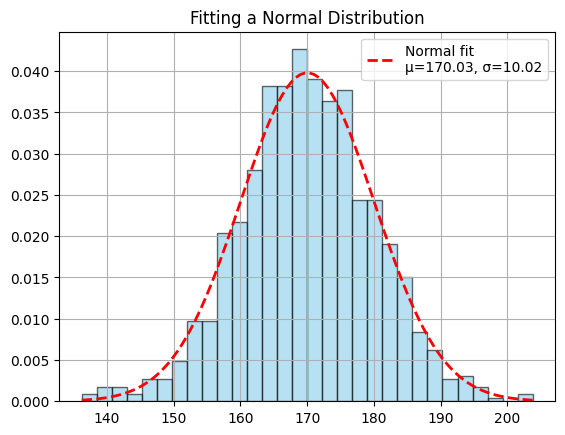

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Example data (e.g., real-world heights in cm)
data = np.random.normal(loc=170, scale=10, size=1000)

# Fit normal distribution to data
mu, sigma = norm.fit(data)

# Plot histogram and PDF
x = np.linspace(min(data), max(data), 100)
pdf = norm.pdf(x, mu, sigma)

plt.hist(data, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black')
plt.plot(x, pdf, 'r--', linewidth=2, label=f'Normal fit\nμ={mu:.2f}, σ={sigma:.2f}')
plt.title("Fitting a Normal Distribution")
plt.legend()
plt.grid(True)
plt.show()


Fitting other distrs

c:\Python312\Lib\site-packages\scipy\stats\_continuous_distns.py:795: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)


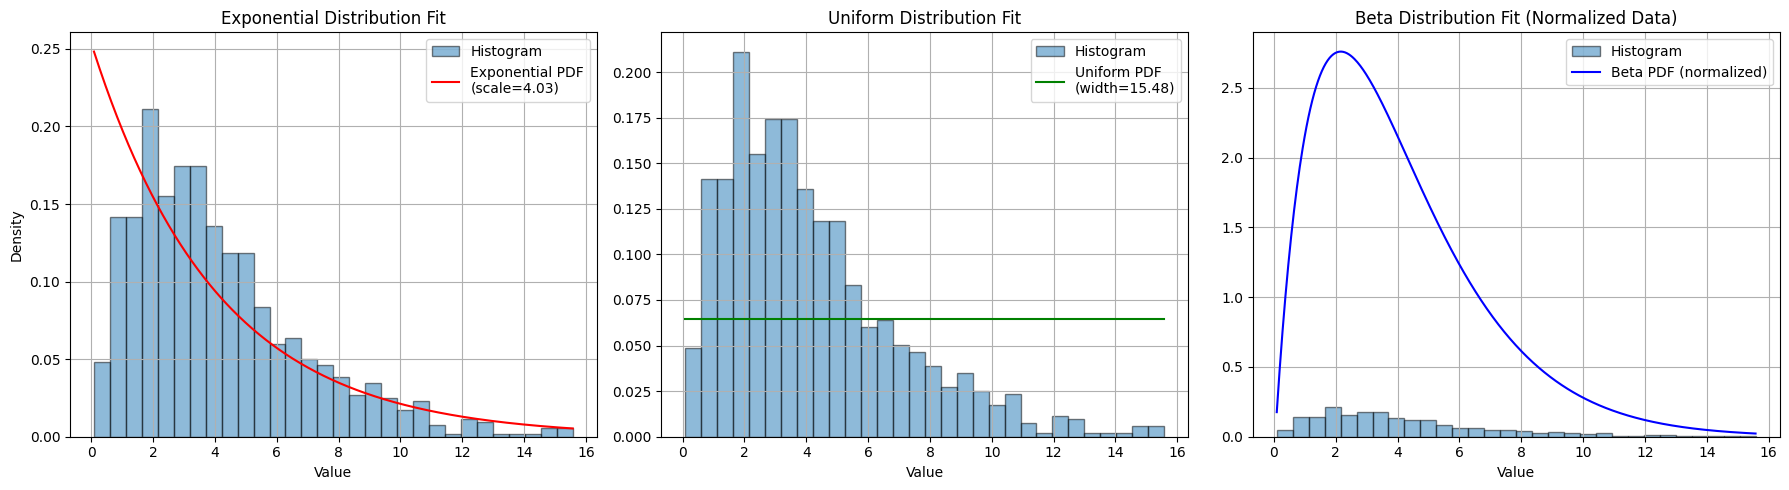

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon, uniform, beta

# Simulate skewed continuous data
np.random.seed(42)
data = np.random.gamma(shape=2, scale=2, size=1000)

# Fit distributions
exp_params = expon.fit(data)
uni_params = uniform.fit(data)
beta_data = (data - np.min(data)) / (np.max(data) - np.min(data))  # Normalize for Beta
beta_params = beta.fit(beta_data)

# X values for plotting
x = np.linspace(min(data), max(data), 500)
x_beta = np.linspace(0, 1, 500)

# PDFs
pdf_exp = expon.pdf(x, *exp_params)
pdf_uni = uniform.pdf(x, *uni_params)
pdf_beta = beta.pdf(x_beta, *beta_params)

# Plot setup: 3 subplots in one row
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
bins = 30

# Plot 1: Exponential Fit
axs[0].hist(data, bins=bins, density=True, alpha=0.5, edgecolor='black', label='Histogram')
axs[0].plot(x, pdf_exp, 'r-', label=f'Exponential PDF\n(scale={exp_params[1]:.2f})')
axs[0].set_title("Exponential Distribution Fit")
axs[0].set_xlabel("Value")
axs[0].set_ylabel("Density")
axs[0].legend()
axs[0].grid(True)

# Plot 2: Uniform Fit
axs[1].hist(data, bins=bins, density=True, alpha=0.5, edgecolor='black', label='Histogram')
axs[1].plot(x, pdf_uni, 'g-', label=f'Uniform PDF\n(width={uni_params[1]:.2f})')
axs[1].set_title("Uniform Distribution Fit")
axs[1].set_xlabel("Value")
axs[1].legend()
axs[1].grid(True)

# Plot 3: Beta Fit on Normalized Data
axs[2].hist(data, bins=bins, density=True, alpha=0.5, edgecolor='black', label='Histogram')
axs[2].plot(x_beta * (np.max(data) - np.min(data)) + np.min(data), pdf_beta, 'b-', label='Beta PDF (normalized)')
axs[2].set_title("Beta Distribution Fit (Normalized Data)")
axs[2].set_xlabel("Value")
axs[2].legend()
axs[2].grid(True)

# Layout and display
plt.tight_layout()
plt.show()


INFERENTIAL STATISTIC


In [ ]:
import numpy as np

# Simulated population: 1 million people heights (mean = 170, std = 10)
population = np.random.normal(loc=170, scale=10, size=1_000_000)

# Draw a sample of 100 people
sample = np.random.choice(population, size=100, replace=False)

# Infer population mean
sample_mean = np.mean(sample)
sample_std = np.std(sample, ddof=1)  # unbiased estimate

print(f"Sample Mean: {sample_mean:.2f}")
print(f"Sample Std Dev: {sample_std:.2f}")


CENTRAL LIMIT THEOREM

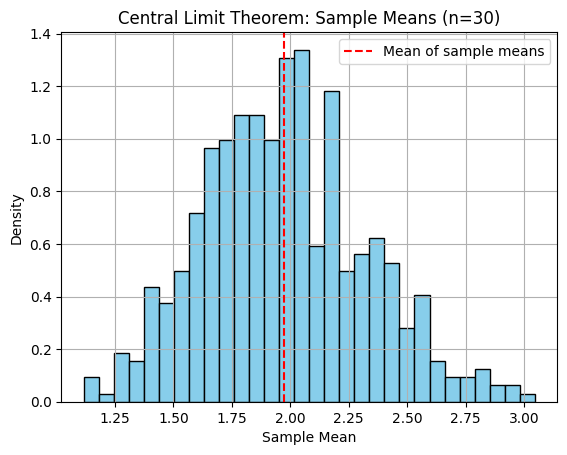

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Population: Exponential (very skewed)
population = np.random.exponential(scale=2.0, size=100_000)

# Draw 500 sample means from samples of size 30
sample_means = []
for _ in range(500):
    sample = np.random.choice(population, size=30)
    sample_means.append(np.mean(sample))

# Plot the distribution of sample means
plt.hist(sample_means, bins=30, color='skyblue', edgecolor='black', density=True)
plt.axvline(np.mean(sample_means), color='red', linestyle='--', label='Mean of sample means')
plt.title("Central Limit Theorem: Sample Means (n=30)")
plt.xlabel("Sample Mean")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()


confidence intervals

In [ ]:
import numpy as np
import scipy.stats as stats

# Sample data
# Generates a random sample of 100 values from a normal distribution.
# The population mean is 50, and the standard deviation is 10.
# np.random.seed(0) makes the results reproducible.
np.random.seed(0)
data = np.random.normal(loc=50, scale=10, size=100)  # sample from population

# Calculate sample statistics
sample_mean = np.mean(data)
sample_std = np.std(data, ddof=1)  # unbiased
n = len(data)

# 95% confidence interval
#Compute Margin of Error
z_score = 1.96
margin_error = z_score * (sample_std / np.sqrt(n))

ci_lower = sample_mean - margin_error
ci_upper = sample_mean + margin_error

print(f"Sample mean: {sample_mean:.2f}")
print(f"95% Confidence Interval: [{ci_lower:.2f}, {ci_upper:.2f}]")

# “The sample mean is 50.59. We’re 95% confident the true population mean is between 48.66 and 52.52.”

# 5. Plot histogram with confidence interval
plt.figure(figsize=(10, 5))
plt.hist(data, bins=20, density=True, alpha=0.6, color='skyblue', edgecolor='black')
plt.axvline(sample_mean, color='red', linestyle='--', linewidth=2, label=f'Mean = {sample_mean:.2f}')
plt.axvline(ci_lower, color='green', linestyle='--', linewidth=2, label=f'Lower CI = {ci_lower:.2f}')
plt.axvline(ci_upper, color='green', linestyle='--', linewidth=2, label=f'Upper CI = {ci_upper:.2f}')
plt.title("Sample Mean and 95% Confidence Interval")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
